<a href="https://colab.research.google.com/github/rajcyrus/capstone-project/blob/main/assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

load cleaned dataset

In [2]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# -------------------------------
# Define Regression Label
# -------------------------------

y_reg = df['SalePrice']

# -------------------------------
# Define Classification Label
# -------------------------------

y_clf = (y_reg > y_reg.median()).astype(int)

# -------------------------------
# Define Feature Matrix
# -------------------------------

X = df.drop(columns=['SalePrice'])

# -------------------------------
# Display Information
# -------------------------------

print("Feature Matrix (X) Shape:", X.shape)
print("Regression Label (y_reg) Shape:", y_reg.shape)
print("Classification Label (y_clf) Shape:", y_clf.shape)

print("\nMedian Sale Price:")
print(y_reg.median())

print("\nClass Distribution:")
print(y_clf.value_counts())

print("\nFirst Five Rows of Feature Matrix:")
print(X.head())

print("\nFirst Five Regression Labels:")
print(y_reg.head())

print("\nFirst Five Classification Labels:")
print(y_clf.head())

Feature Matrix (X) Shape: (2930, 81)
Regression Label (y_reg) Shape: (2930,)
Classification Label (y_clf) Shape: (2930,)

Median Sale Price:
160000.0

Class Distribution:
SalePrice
0    1467
1    1463
Name: count, dtype: int64

First Five Rows of Feature Matrix:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Screen Porch Pool Area Pool QC  Fence  \
0   NaN       IR1          Lvl  ...            0         0     NaN    NaN   
1   NaN       Reg          Lvl  ...          120         0     NaN  MnPrv   
2   NaN       IR1          Lvl  ...        

Encode categorical columns

In [3]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# ---------------------------------------
# Define Features and Target
# ---------------------------------------

X = df.drop(columns=['SalePrice'])
y_reg = df['SalePrice']
y_clf = (y_reg > y_reg.median()).astype(int)

# ---------------------------------------
# Identify categorical columns
# ---------------------------------------

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:")
print(list(categorical_cols))

# ---------------------------------------
# One-Hot Encoding
# ---------------------------------------

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("\nShape Before Encoding :", X.shape)
print("Shape After Encoding  :", X_encoded.shape)

print("\nFirst Five Rows:")
print(X_encoded.head())

Categorical Columns:
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

Shape Before Encoding : (2930, 81)
Shape After Encoding  : (2930, 262)

First Five Rows:
   Order        PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
0      1  526301100           20         141.0     31770             6   
1      2  526350040           20          80.0     11622             5   
2      3  526351010           20          81.0    

Leak-free train-test split and scaling:

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------------------
# Load the cleaned dataset
# ----------------------------------------

df = pd.read_csv("cleaned_data.csv")

# ----------------------------------------
# Define Features and Labels
# ----------------------------------------

# Regression Target
y_reg = df['SalePrice']

# Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

# Feature Matrix
X = df.drop(columns=['SalePrice'])

# ----------------------------------------
# One-Hot Encode Categorical Variables
# ----------------------------------------

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# ----------------------------------------
# Train-Test Split (Regression)
# ----------------------------------------

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

# ----------------------------------------
# Train-Test Split (Classification)
# ----------------------------------------

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

# ----------------------------------------
# Feature Scaling
# ----------------------------------------

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train_reg)

# Transform training and testing data
X_train_reg_scaled = scaler.transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

# Use the same scaler for classification
X_train_clf_scaled = scaler.transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

# ----------------------------------------
# Display Shapes
# ----------------------------------------

print("Regression Dataset")
print("Training Features :", X_train_reg_scaled.shape)
print("Testing Features  :", X_test_reg_scaled.shape)
print("Training Labels   :", y_train_reg.shape)
print("Testing Labels    :", y_test_reg.shape)

print("\nClassification Dataset")
print("Training Features :", X_train_clf_scaled.shape)
print("Testing Features  :", X_test_clf_scaled.shape)
print("Training Labels   :", y_train_clf.shape)
print("Testing Labels    :", y_test_clf.shape)

Regression Dataset
Training Features : (2344, 262)
Testing Features  : (586, 262)
Training Labels   : (2344,)
Testing Labels    : (586,)

Classification Dataset
Training Features : (2344, 262)
Testing Features  : (586, 262)
Training Labels   : (2344,)
Testing Labels    : (586,)


egression model — Linear Regression:

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("cleaned_data.csv")

# ==========================================================
# Define Features and Target
# ==========================================================

X = df.drop(columns=['SalePrice'])
y_reg = df['SalePrice']

# ==========================================================
# One-Hot Encode Categorical Columns
# ==========================================================

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

feature_names = X.columns

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# Linear Regression
# ==========================================================

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("----------- Linear Regression -----------")
print("MSE :", mse_lr)
print("R²  :", r2_lr)

# ==========================================================
# Coefficients
# ==========================================================

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
})

coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print("\nTop 3 Features with Largest Absolute Coefficients")
print(coef_df[['Feature','Coefficient']].head(3))

print("\nAll Coefficients")
print(coef_df[['Feature','Coefficient']])

# ==========================================================
# Ridge Regression
# ==========================================================

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n----------- Ridge Regression -----------")
print("MSE :", mse_ridge)
print("R²  :", r2_ridge)

# ==========================================================
# Comparison Table
# ==========================================================

comparison = pd.DataFrame({
    'Model': ['Linear Regression','Ridge Regression'],
    'MSE': [mse_lr,mse_ridge],
    'R² Score': [r2_lr,r2_ridge]
})

print("\nModel Comparison")
print(comparison)

----------- Linear Regression -----------
MSE : 834182322.2214183
R²  : 0.8959554305867466

Top 3 Features with Largest Absolute Coefficients
          Feature    Coefficient
10   BsmtFin SF 1  133328.896106
12    Bsmt Unf SF  120065.284955
13  Total Bsmt SF -112078.084464

All Coefficients
                  Feature   Coefficient
10           BsmtFin SF 1  1.333289e+05
12            Bsmt Unf SF  1.200653e+05
13          Total Bsmt SF -1.120781e+05
118     Roof Matl_CompShg  7.627960e+04
122     Roof Matl_Tar&Grv  5.523329e+04
..                    ...           ...
141  Exterior 2nd_Brk Cmn  2.550572e+01
219       Fireplace Qu_Po -2.417953e+01
148    Exterior 2nd_Other  5.727088e-09
208       Kitchen Qual_Po  2.273737e-13
247     Misc Feature_TenC  0.000000e+00

[262 rows x 2 columns]

----------- Ridge Regression -----------
MSE : 829823305.0623978
R²  : 0.8964991151641991

Model Comparison
               Model           MSE  R² Score
0  Linear Regression  8.341823e+08  0.895955
1   R

Classification model — Logistic Regression:

Training Class Distribution
SalePrice
0    1186
1    1158
Name: count, dtype: int64

Percentage Distribution
SalePrice
0    50.59727
1    49.40273
Name: proportion, dtype: float64

Confusion Matrix
[[264  17]
 [ 22 283]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       281
           1       0.94      0.93      0.94       305

    accuracy                           0.93       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.93      0.93      0.93       586

Accuracy : 0.9334470989761092
AUC : 0.9792077475059798


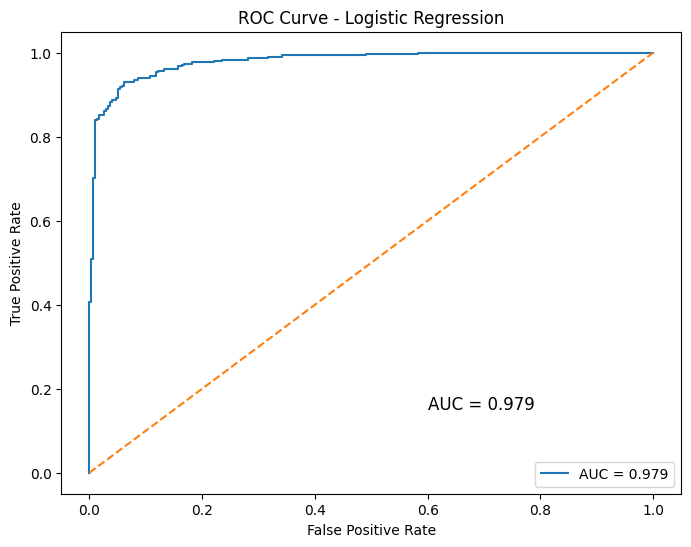

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("cleaned_data.csv")

# ==========================================================
# Features and Labels
# ==========================================================

X = df.drop(columns=['SalePrice'])

y_reg = df['SalePrice']

y_clf = (y_reg > y_reg.median()).astype(int)

# ==========================================================
# One-Hot Encoding
# ==========================================================

categorical_cols = X.select_dtypes(include=['object','category']).columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# Check Class Balance
# ==========================================================

print("Training Class Distribution")

print(y_train.value_counts())

print("\nPercentage Distribution")

print(y_train.value_counts(normalize=True)*100)

# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ==========================================================
# Logistic Regression
# ==========================================================

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

# ==========================================================
# Prediction
# ==========================================================

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix")

print(cm)

# ==========================================================
# Classification Metrics
# ==========================================================

print("\nClassification Report")

print(classification_report(y_test,y_pred))

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

# ==========================================================
# ROC Curve
# ==========================================================

fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC :",auc)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend(loc="lower right")

plt.text(
    0.60,
    0.15,
    f"AUC = {auc:.3f}",
    fontsize=12
)

plt.show()

Decision-threshold sensitivity

In [7]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# ---------------------------------------------------
# Predicted Probabilities
# ---------------------------------------------------

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Thresholds to evaluate
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    # Convert probabilities into class labels
    y_pred = (y_prob >= threshold).astype(int)

    # Compute evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([threshold, precision, recall, f1])

# Create a results table
results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(results_df)

   Threshold  Precision    Recall  F1 Score
0        0.3   0.897516  0.947541  0.921850
1        0.4   0.919872  0.940984  0.930308
2        0.5   0.943333  0.927869  0.935537
3        0.6   0.952055  0.911475  0.931323
4        0.7   0.957597  0.888525  0.921769


Regularization experiment on Logistic Regression:

In [8]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)

# ==========================================================
# Baseline Logistic Regression (C = 1.0)
# ==========================================================

baseline_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)
baseline_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

# ==========================================================
# Strongly Regularized Logistic Regression (C = 0.01)
# ==========================================================

regularized_model = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

regularized_model.fit(X_train_scaled, y_train)

regularized_pred = regularized_model.predict(X_test_scaled)
regularized_prob = regularized_model.predict_proba(X_test_scaled)[:, 1]

regularized_precision = precision_score(y_test, regularized_pred)
regularized_recall = recall_score(y_test, regularized_pred)
regularized_auc = roc_auc_score(y_test, regularized_prob)

# ==========================================================
# Comparison Table
# ==========================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (C=1.0)",
        "Logistic Regression (C=0.01)"
    ],
    "Precision": [
        baseline_precision,
        regularized_precision
    ],
    "Recall": [
        baseline_recall,
        regularized_recall
    ],
    "AUC": [
        baseline_auc,
        regularized_auc
    ]
})

print(comparison)

                          Model  Precision    Recall       AUC
0   Logistic Regression (C=1.0)   0.943333  0.927869  0.979208
1  Logistic Regression (C=0.01)   0.963087  0.940984  0.990736


Bootstrap confidence interval for AUC difference:

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# ==========================================================
# Predicted probabilities from the two models
# (These should already exist from the previous task)
# ==========================================================

# baseline_prob      -> C = 1.0 model probabilities
# regularized_prob   -> C = 0.01 model probabilities
# y_test             -> True binary labels

# ==========================================================
# Bootstrap Parameters
# ==========================================================

n_bootstrap = 500
auc_differences = []

np.random.seed(42)

# ==========================================================
# Bootstrap Sampling
# ==========================================================

for i in range(n_bootstrap):

    # Sample indices with replacement
    indices = np.random.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    # Bootstrap sample
    y_boot = y_test.iloc[indices]

    prob_baseline = baseline_prob[indices]
    prob_regularized = regularized_prob[indices]

    # Skip samples containing only one class
    if len(np.unique(y_boot)) < 2:
        continue

    # Compute AUCs
    auc_baseline = roc_auc_score(
        y_boot,
        prob_baseline
    )

    auc_regularized = roc_auc_score(
        y_boot,
        prob_regularized
    )

    # Store difference
    auc_differences.append(
        auc_baseline - auc_regularized
    )

# ==========================================================
# Confidence Interval
# ==========================================================

mean_difference = np.mean(auc_differences)

lower_ci = np.percentile(
    auc_differences,
    2.5
)

upper_ci = np.percentile(
    auc_differences,
    97.5
)

# ==========================================================
# Results
# ==========================================================

print("Bootstrap Results")
print("---------------------------")
print(f"Mean AUC Difference : {mean_difference:.5f}")
print(f"95% CI Lower Bound  : {lower_ci:.5f}")
print(f"95% CI Upper Bound  : {upper_ci:.5f}")

# Check whether zero lies inside the interval
if lower_ci > 0 or upper_ci < 0:
    print("\nThe 95% confidence interval excludes zero.")
    print("The performance difference is likely reliable.")
else:
    print("\nThe 95% confidence interval includes zero.")
    print("The performance difference may not be statistically reliable.")

Bootstrap Results
---------------------------
Mean AUC Difference : -0.01165
95% CI Lower Bound  : -0.01870
95% CI Upper Bound  : -0.00550

The 95% confidence interval excludes zero.
The performance difference is likely reliable.
